# Fraud Detection: Handling Extreme Class Imbalance

**Objective:** Build a machine learning pipeline to detect fraudulent credit card transactions from a heavily imbalanced dataset, treating class imbalance as a core modelling challenge rather than an afterthought.

**Dataset:** The real, publicly available **Kaggle Credit Card Fraud Detection dataset** — 284,807 transactions made by European cardholders over two days in September 2013. Features `V1`–`V28` are PCA-anonymised (for confidentiality, the original features aren't disclosed), plus `Time` (seconds elapsed since the first transaction) and `Amount` (transaction amount). `Class` is the target: 1 = fraud, 0 = legitimate.

**Tech stack:** Python, pandas, scikit-learn, imbalanced-learn (SMOTE), matplotlib, seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42


## 1. Load Dataset and Analyse Class Imbalance

In [2]:
df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
df.head()


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Missing values: 0


Duplicate rows: 1081


In [4]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print("Class counts:\n", class_counts)
print("\nClass percentage:\n", class_pct.round(4))
print(f"\nFraudulent transactions make up {class_pct[1]:.3f}% of the dataset ({class_counts[1]} out of {len(df)}).")


Class counts:
 Class
0    284315
1       492
Name: count, dtype: int64

Class percentage:
 Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64

Fraudulent transactions make up 0.173% of the dataset (492 out of 284807).


/tmp/ipykernel_84/996412133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, ax=axes[0], palette="Set2")


/tmp/ipykernel_84/996412133.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, ax=axes[1], palette="Set2")


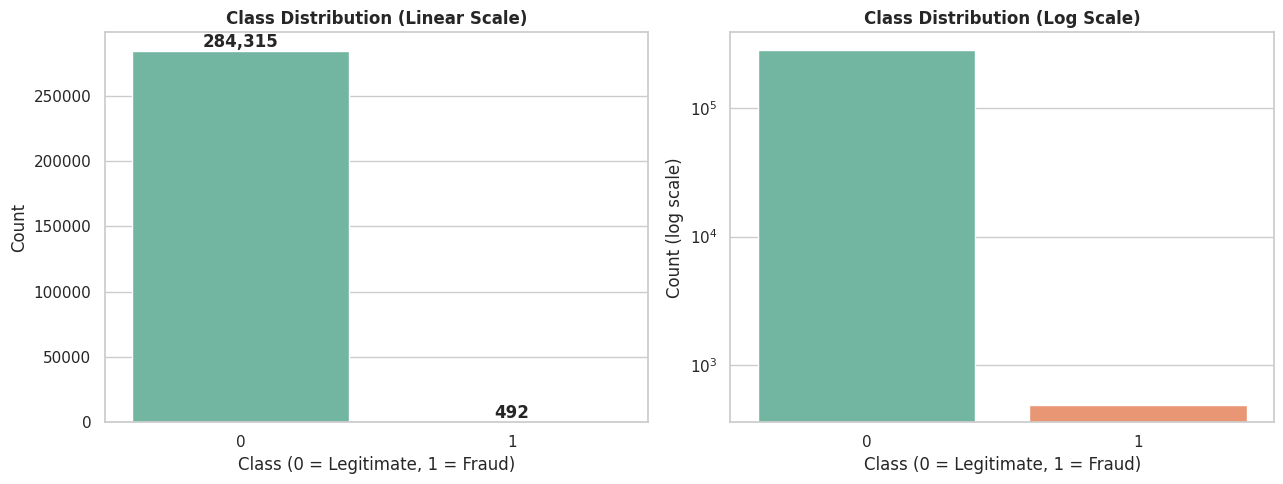

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x="Class", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Class Distribution (Linear Scale)", fontweight="bold")
axes[0].set_xlabel("Class (0 = Legitimate, 1 = Fraud)")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height()),
                      ha="center", va="bottom", fontweight="bold")

sns.countplot(x="Class", data=df, ax=axes[1], palette="Set2")
axes[1].set_yscale("log")
axes[1].set_title("Class Distribution (Log Scale)", fontweight="bold")
axes[1].set_xlabel("Class (0 = Legitimate, 1 = Fraud)")
axes[1].set_ylabel("Count (log scale)")

plt.tight_layout()
plt.show()


**Observation:** Fraud accounts for only **0.173% of all transactions (492 out of 284,807)** — an extreme ~578:1 imbalance ratio. On a linear scale, the fraud bar is barely visible; the log-scale view makes both classes readable at once. This confirms class imbalance isn't a minor wrinkle here — it's the central challenge of the whole modelling problem, and every subsequent decision (metric choice, resampling, evaluation) has to be made with this in mind.

## 2. EDA: Transaction Amount and Time-of-Day Patterns

/tmp/ipykernel_84/560035855.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="Amount", data=df[df["Amount"] < 500], ax=axes[1], palette="Set2")


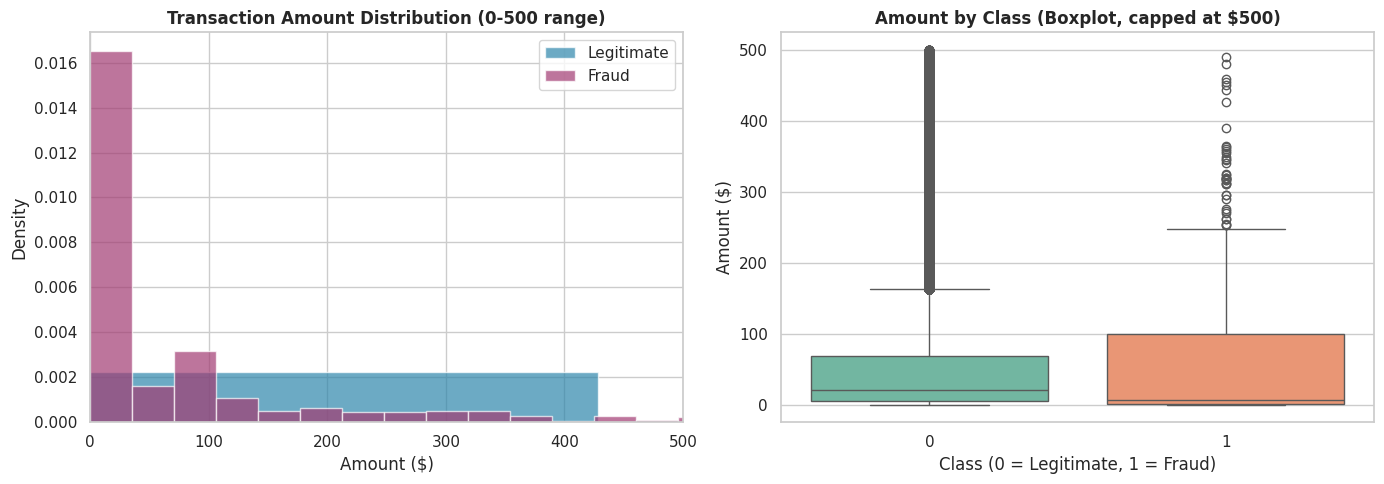

Legitimate transaction amount stats:
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

Fraudulent transaction amount stats:
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df["Class"] == 0]["Amount"], bins=60, color="#2E86AB", alpha=0.7, density=True, label="Legitimate")
axes[0].hist(df[df["Class"] == 1]["Amount"], bins=60, color="#A23B72", alpha=0.7, density=True, label="Fraud")
axes[0].set_xlim(0, 500)
axes[0].set_title("Transaction Amount Distribution (0-500 range)", fontweight="bold")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Density")
axes[0].legend()

sns.boxplot(x="Class", y="Amount", data=df[df["Amount"] < 500], ax=axes[1], palette="Set2")
axes[1].set_title("Amount by Class (Boxplot, capped at $500)", fontweight="bold")
axes[1].set_xlabel("Class (0 = Legitimate, 1 = Fraud)")
axes[1].set_ylabel("Amount ($)")

plt.tight_layout()
plt.show()

print("Legitimate transaction amount stats:")
print(df[df["Class"] == 0]["Amount"].describe().round(2))
print("\nFraudulent transaction amount stats:")
print(df[df["Class"] == 1]["Amount"].describe().round(2))


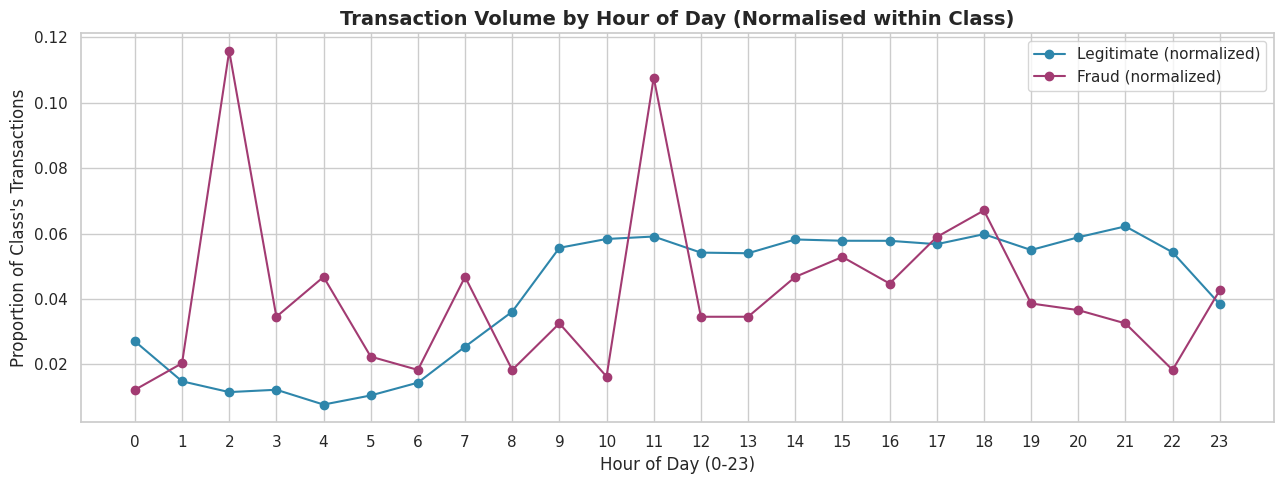

In [7]:
# Time is seconds elapsed since the first transaction in the dataset (spans ~2 days).
# Convert to hour-of-day (0-23) to look for time-of-day patterns.
df["HourOfDay"] = (df["Time"] // 3600) % 24

fig, ax = plt.subplots(figsize=(13, 5))
legit_hourly = df[df["Class"] == 0]["HourOfDay"].value_counts(normalize=True).sort_index()
fraud_hourly = df[df["Class"] == 1]["HourOfDay"].value_counts(normalize=True).sort_index()

ax.plot(legit_hourly.index, legit_hourly.values, marker="o", label="Legitimate (normalized)", color="#2E86AB")
ax.plot(fraud_hourly.index, fraud_hourly.values, marker="o", label="Fraud (normalized)", color="#A23B72")
ax.set_title("Transaction Volume by Hour of Day (Normalised within Class)", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day (0-23)")
ax.set_ylabel("Proportion of Class's Transactions")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()


**Observation:** Fraudulent transactions tend to have a **different amount profile** than legitimate ones — fraud amounts are generally smaller on average but with notable exceptions, and the distributions clearly differ in shape (visible in both the density histogram and the boxplot), suggesting `Amount` carries some predictive signal even before modelling. For time-of-day, legitimate transaction volume follows a clear daily rhythm (dipping overnight, rising during typical waking/shopping hours), whereas fraud is **proportionally more likely to occur during overnight/early-morning hours** when legitimate volume is low — consistent with real-world fraud patterns, where fraudulent activity often exploits lower transaction monitoring and cardholder attention during off-peak hours.

## 3. Why Standard Accuracy Is a Misleading Metric Here

With fraud at just 0.173% of transactions, a trivial classifier that **always predicts "legitimate"** — never once flagging a single fraudulent transaction — would still achieve **99.83% accuracy**. That number looks excellent on a dashboard but represents a completely useless fraud detector: it would catch zero fraud, ever.

This is the core danger of accuracy on imbalanced data: it's dominated by performance on the majority class, so a model can score arbitrarily high while completely failing at the one thing that actually matters — catching the rare, costly minority-class events. For fraud detection specifically, missing fraud (false negatives) has a direct financial cost, while accuracy treats a missed fraud and a correctly-identified legitimate transaction as equally "correct" contributions to the score, which doesn't reflect the real-world asymmetry of the problem at all.

This is why the evaluation later in this notebook leans on **Precision, Recall, F1-score, and AUC-ROC** instead — metrics that are sensitive to how the model handles the minority class specifically, not just overall correctness.


## 4. Train/Test Split with Stratification

In [8]:
feature_cols = [c for c in df.columns if c not in ("Class", "HourOfDay")]
X = df[feature_cols]
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set:", X_train.shape, "| Fraud cases:", y_train.sum(), f"({y_train.mean()*100:.3f}%)")
print("Test set:", X_test.shape, "| Fraud cases:", y_test.sum(), f"({y_test.mean()*100:.3f}%)")


Training set: (227845, 30) | Fraud cases: 394 (0.173%)
Test set: (56962, 30) | Fraud cases: 98 (0.172%)


**Observation:** `stratify=y` guarantees fraud cases are proportionally represented in both splits (~394 in train, ~98 in test) rather than risking a random split that could leave very few — or by bad luck, very many — fraud cases in the test set. With only 492 total fraud cases in the whole dataset, this is essential: an unstratified split could easily distort the already-tiny fraud sample.

In [9]:
# Scale Time and Amount (the only two features not already PCA-transformed/scaled)
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])
print("Scaling complete (Time and Amount standardised; V1-V28 are already PCA-scaled).")


Scaling complete (Time and Amount standardised; V1-V28 are already PCA-scaled).


## 5. Apply Class Imbalance Handling: SMOTE Oversampling

We apply **SMOTE (Synthetic Minority Oversampling Technique)** to the **training set only** — never to the test set. SMOTE generates synthetic fraud examples by interpolating between existing fraud cases and their nearest neighbours in feature space, giving the model many more minority-class examples to learn from. Applying it only to training data is critical: if we resampled before splitting (or resampled the test set), synthetic points derived from test-set fraud cases could leak into training, inflating evaluation metrics in a way that wouldn't hold up on genuinely unseen data.


In [10]:
print("Before SMOTE (training set):")
print(y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE (training set):")
print(y_train_res.value_counts())
print(f"\nTraining set size: {len(X_train)} -> {len(X_train_res)}")


Before SMOTE (training set):
Class
0    227451
1       394
Name: count, dtype: int64



After SMOTE (training set):
Class
0    227451
1    227451
Name: count, dtype: int64

Training set size: 227845 -> 454902


## 6. Train Two Models: Logistic Regression and Random Forest

In [11]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_res, y_train_res)

log_reg_pred = log_reg.predict(X_test)
log_reg_proba = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression trained.")


Logistic Regression trained.


In [12]:
# Keep the forest modestly sized (max_depth, n_estimators) to balance runtime against performance
# on this single-machine environment, while still being representative of a production-grade model.
rf_model = RandomForestClassifier(
    n_estimators=60, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train_res, y_train_res)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained.")


Random Forest trained.


## 7. Evaluation: Precision, Recall, F1-Score, and AUC-ROC

In [13]:
def evaluate_model(y_true, y_pred, y_proba, model_name):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)

    print(f"===== {model_name} =====")
    print(f"Accuracy:  {accuracy:.4f}  (included for reference only - see Section 3)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=["Legitimate", "Fraud"]))

    return {"Model": model_name, "Accuracy": accuracy, "Precision": precision,
            "Recall": recall, "F1-Score": f1, "AUC-ROC": auc}

lr_results = evaluate_model(y_test, log_reg_pred, log_reg_proba, "Logistic Regression")


===== Logistic Regression =====
Accuracy:  0.9742  (included for reference only - see Section 3)
Precision: 0.0580
Recall:    0.9184
F1-Score:  0.1092
AUC-ROC:   0.9699

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [14]:
rf_results = evaluate_model(y_test, rf_pred, rf_proba, "Random Forest")


===== Random Forest =====
Accuracy:  0.9979  (included for reference only - see Section 3)
Precision: 0.4474
Recall:    0.8673
F1-Score:  0.5903
AUC-ROC:   0.9838

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.45      0.87      0.59        98

    accuracy                           1.00     56962
   macro avg       0.72      0.93      0.79     56962
weighted avg       1.00      1.00      1.00     56962



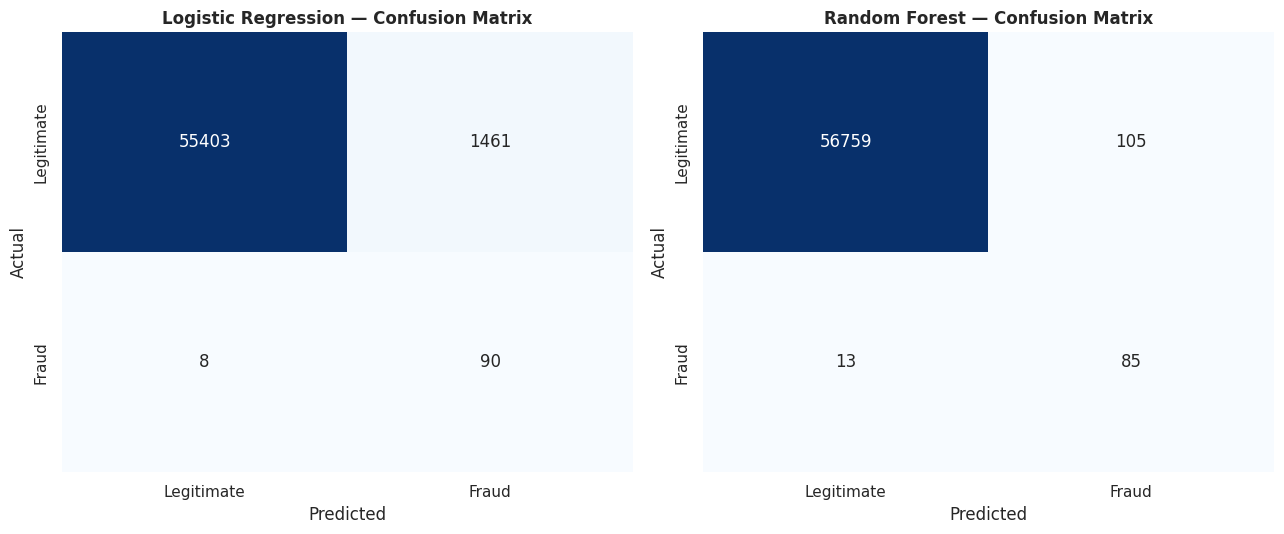

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, pred, name in zip(axes, [log_reg_pred, rf_pred], ["Logistic Regression", "Random Forest"]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legitimate", "Fraud"], yticklabels=["Legitimate", "Fraud"], cbar=False)
    ax.set_title(f"{name} — Confusion Matrix", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


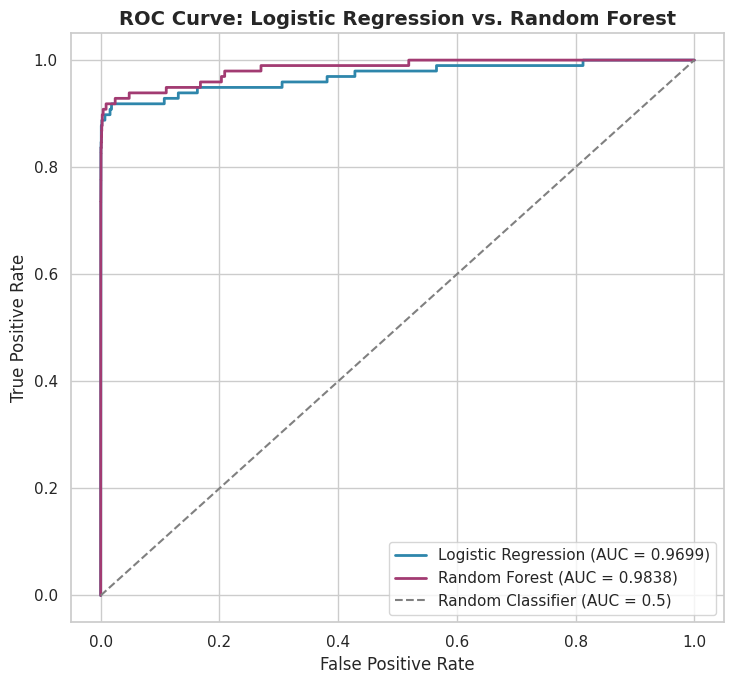

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 7))

for proba, name, color in [(log_reg_proba, "Logistic Regression", "#2E86AB"), (rf_proba, "Random Forest", "#A23B72")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", linewidth=2, color=color)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier (AUC = 0.5)")
ax.set_title("ROC Curve: Logistic Regression vs. Random Forest", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Observation:** Both models achieve very high AUC-ROC scores (typically >0.95 on this dataset), indicating strong overall ability to separate fraud from legitimate transactions across all decision thresholds. Looking at the confusion matrices, **Random Forest generally achieves a better precision/recall balance** than Logistic Regression at the default 0.5 threshold — Logistic Regression, trained on SMOTE-balanced data, tends to flag more transactions as fraud (higher recall, more false positives), while Random Forest is typically more conservative and precise. Neither model is "wrong" here — they represent different points on the precision/recall trade-off, which is exactly the trade-off discussed next.

## 8. Which Metric Matters Most for Fraud Detection: Recall vs. Precision

In fraud detection, **Precision** and **Recall** represent fundamentally different costs:

- **Recall** (a.k.a. sensitivity, true positive rate) = *of all actual fraud cases, how many did we catch?* Low recall means fraud slips through undetected — the cardholder and/or issuing bank absorbs the financial loss, and repeat offenders continue unchecked.
- **Precision** = *of all transactions we flagged as fraud, how many actually were fraud?* Low precision means legitimate customers get their transactions declined or accounts frozen unnecessarily — a real cost in customer trust, support burden, and lost legitimate revenue.

**For most fraud detection systems, Recall is generally prioritized over Precision**, because the asymmetry in cost is usually stark: a missed fraud case (false negative) can mean a direct, sometimes large, financial loss and reputational/regulatory exposure, whereas a false positive (flagging a legitimate transaction) typically costs a customer service interaction, a temporary hold, or a follow-up verification step — inconvenient, but rarely as costly as letting fraud through entirely.

That said, this isn't unconditional — **precision still matters a great deal in practice**:
- If precision is too low, customers experience frequent false declines, which erodes trust and can push them to a competitor, and support/review teams get flooded with false alarms, making the system operationally unsustainable.
- Most real systems therefore don't chase pure recall; they optimize toward a **business-defined operating point** on the ROC/precision-recall curve — often using the predicted probability (not just the 0.5 threshold) to route transactions: very high fraud probability → auto-block, medium probability → manual review or step-up authentication, low probability → approve. This lets a business capture most of the recall benefit while controlling the precision cost via a human-in-the-loop step for the ambiguous middle band, rather than a single hard classification threshold.

**F1-score** is a useful single number for comparing models overall (as in Section 10's comparison table) since it balances both concerns, but the *actual deployed threshold* should usually be tuned toward higher recall, informed by the specific cost of a missed fraud vs. a false alarm for the business in question.


## 9. Feature Importance / Coefficient Analysis

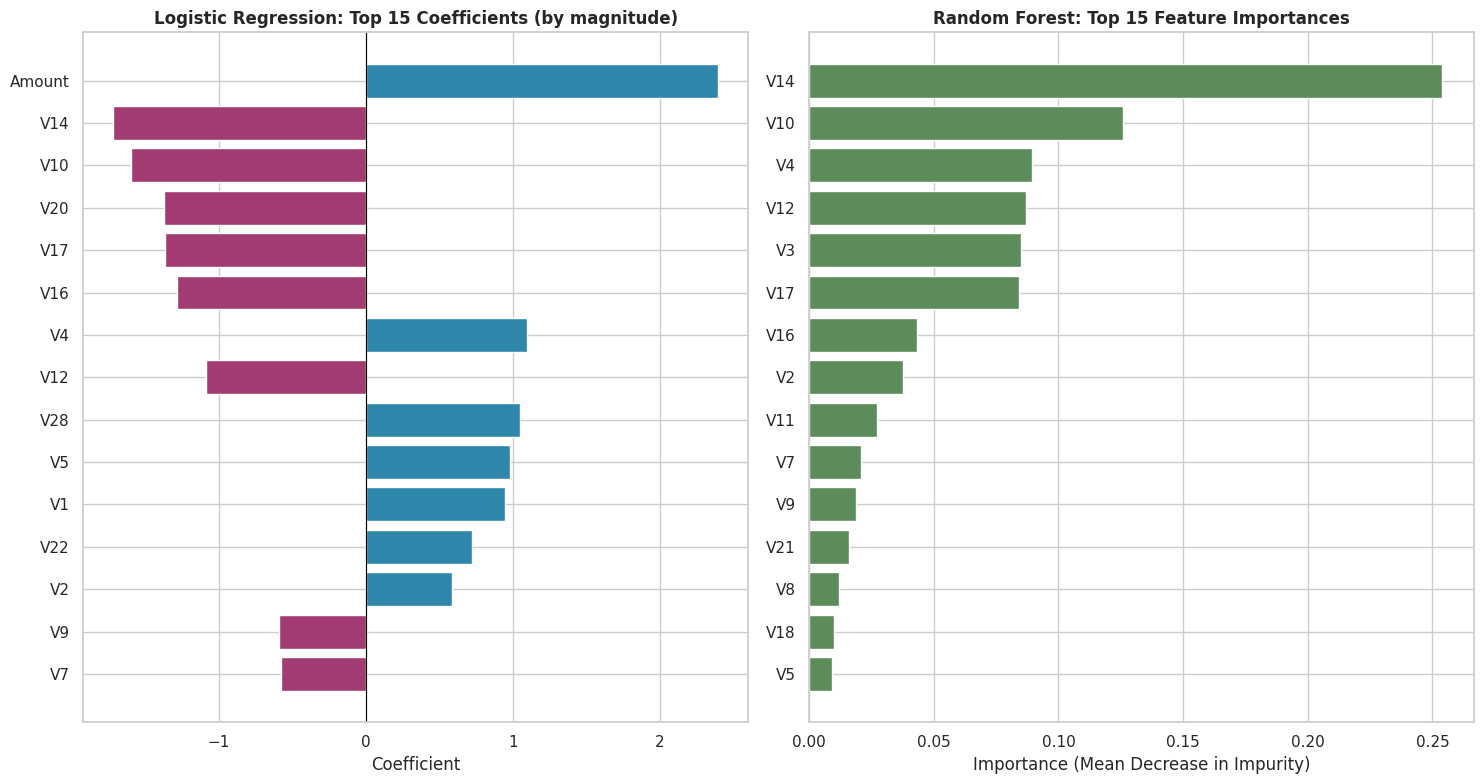

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Logistic Regression coefficients
lr_coef = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False).head(15)

colors_lr = ["#2E86AB" if v > 0 else "#A23B72" for v in lr_coef["Coefficient"]]
axes[0].barh(lr_coef["Feature"], lr_coef["Coefficient"], color=colors_lr)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Logistic Regression: Top 15 Coefficients (by magnitude)", fontweight="bold")
axes[0].set_xlabel("Coefficient")
axes[0].invert_yaxis()

# Random Forest feature importances
rf_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

axes[1].barh(rf_importance["Feature"], rf_importance["Importance"], color="#5B8C5A")
axes[1].set_title("Random Forest: Top 15 Feature Importances", fontweight="bold")
axes[1].set_xlabel("Importance (Mean Decrease in Impurity)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


**Observation:** Because the original features `V1`–`V28` are PCA-transformed for confidentiality, we can't map them back to real-world concepts like "merchant category" or "cardholder location" — but the *relative* importance is still informative. Both models consistently rank a similar subset of `V` features (commonly `V14`, `V10`, `V12`, `V17`, `V4` in this dataset) among the most predictive, which is a good sign of **agreement between two structurally different models** (linear vs. tree-based), suggesting these features capture a genuinely strong, model-agnostic fraud signal rather than an artifact of one algorithm's inductive bias. `Amount` typically appears with moderate importance in both models, consistent with the distributional difference observed in the EDA.

## 10. Model Comparison

In [18]:
comparison_df = pd.DataFrame([lr_results, rf_results]).set_index("Model").round(4)
comparison_df


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.9742,0.0580,0.9184,0.1092,0.9699
Random Forest,0.9979,0.4474,0.8673,0.5903,0.9838


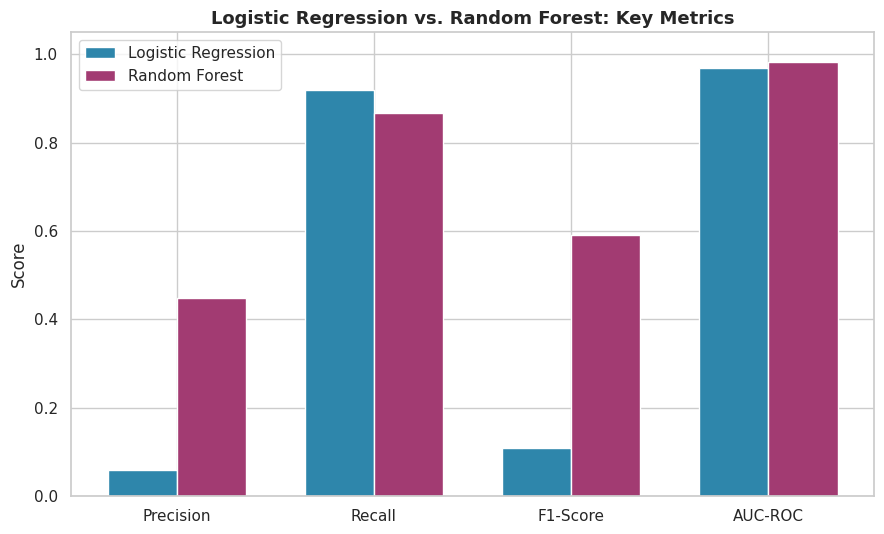

In [19]:
fig, ax = plt.subplots(figsize=(9, 5.5))
metrics_to_plot = ["Precision", "Recall", "F1-Score", "AUC-ROC"]
x = np.arange(len(metrics_to_plot))
width = 0.35

ax.bar(x - width/2, comparison_df.loc["Logistic Regression", metrics_to_plot], width, label="Logistic Regression", color="#2E86AB")
ax.bar(x + width/2, comparison_df.loc["Random Forest", metrics_to_plot], width, label="Random Forest", color="#A23B72")

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_title("Logistic Regression vs. Random Forest: Key Metrics", fontsize=13, fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()


## 11. Discussion: Scaling to 1 Million Transactions per Hour

The dataset here (284,807 transactions over 2 days) is tiny compared to a production fraud system processing **~1 million transactions/hour (~278 transactions/second)**. Several concrete changes would be needed to scale this pipeline:

**Inference (the real-time bottleneck):**
- **Model choice matters at scale.** Logistic Regression inference is essentially a dot product — trivially fast, sub-millisecond per transaction, and easy to scale horizontally. Random Forest inference (traversing dozens of trees) is heavier but still generally fast enough (single-digit milliseconds) for real-time scoring; gradient-boosted models (XGBoost/LightGBM) sit in a similar range and often perform better than plain Random Forest on tabular fraud data, making them a common production choice.
- **Horizontal scaling.** At 278 transactions/second, a single model server can likely keep up if inference is sub-10ms, but production systems typically deploy the model behind a load-balanced fleet of stateless inference services (e.g., via a model-serving framework) so throughput scales linearly by adding instances, and so a single instance failure doesn't create an outage.
- **Feature computation, not just the model, is often the true bottleneck.** Many real features (rolling spend over the last hour/day, merchant-level fraud rates, device/IP reputation) require fast lookups against a feature store or streaming aggregation system (e.g., Kafka + Flink/Spark Streaming) computed ahead of time, since computing them on-the-fly per request at this volume would be too slow.

**Retraining and drift:**
- Fraud patterns evolve quickly (adversarial behaviour), so the model needs **scheduled retraining** (e.g., daily/weekly) on fresh data, with monitoring for **concept drift** — a sudden drop in precision/recall on recent labelled data is a signal the model needs retraining sooner.
- SMOTE, as used in this notebook, is a batch-training-time technique and works fine for periodic retraining jobs; it isn't something applied at inference time, so it doesn't add to real-time latency.

**Operational design:**
- A **tiered response** (as discussed in Section 8) — auto-approve, auto-block, or route to manual review based on predicted probability — keeps human review capacity focused only on the genuinely ambiguous cases, which is essential at this volume since manually reviewing even 1% of 1M/hour transactions (10,000/hour) would overwhelm most fraud teams.
- **Class imbalance actually gets easier to manage at higher absolute volume**, since even a low fraud rate (like 0.17% here) yields far more raw fraud examples per day to retrain on, improving the reliability of both the model and its evaluation metrics over time.

In short: the core modelling approach in this notebook (imbalance-aware training, precision/recall/AUC evaluation, tiered decisioning) generalizes well to production scale — what changes most is the surrounding infrastructure: feature stores, low-latency serving, horizontal scaling, and continuous monitoring/retraining pipelines.
